In [1]:
# ============================================================
# 0. 기본 라이브러리 불러오기
# ============================================================

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 장치:", device)

사용 장치: cuda


In [2]:
# ============================================================
# 1. 데이터 준비
# ============================================================

breast = load_breast_cancer()

Xdf = pd.DataFrame(breast.data, columns=breast.feature_names)
yseries = pd.Series(breast.target, name="diagnosis_raw")

print("sklearn target_names:", breast.target_names)
print("입력 데이터 크기:", Xdf.shape)
print("라벨 데이터 크기:", yseries.shape)

display(Xdf.head())

ylabel = yseries.map({1: "Benignant", 0: "Malevolent"})
yencoded = ylabel.map({"Benignant": 0, "Malevolent": 1}).values

print("\n라벨 분포")
print(ylabel.value_counts())
print("\n라벨 비율(%)")
print(round(ylabel.value_counts(normalize=True) * 100, 2))

sklearn target_names: ['malignant' 'benign']
입력 데이터 크기: (569, 30)
라벨 데이터 크기: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



라벨 분포
diagnosis_raw
Benignant     357
Malevolent    212
Name: count, dtype: int64

라벨 비율(%)
diagnosis_raw
Benignant     62.74
Malevolent    37.26
Name: proportion, dtype: float64


In [3]:
# ============================================================
# 2. 일부 컬럼 통계 확인
# ============================================================

selectedcolumns = ["mean radius", "mean area", "mean texture"]
print("\n선택 컬럼 기술통계")
display(Xdf[selectedcolumns].describe())


선택 컬럼 기술통계


,mean radius,mean area,mean texture
count,569.000000,569.000000,569.000000
mean,14.127292,654.889104,19.289649
std,3.524049,351.914129,4.301036
min,6.981000,143.500000,9.710000
25%,11.700000,420.300000,16.170000
50%,13.370000,551.100000,18.840000
75%,15.780000,782.700000,21.800000
max,28.110000,2501.000000,39.280000


In [4]:
# ============================================================
# 3. Min-Max 정규화 함수
# ============================================================

def minmaxnormalize(df):
    minvalue = df.min()
    maxvalue = df.max()
    eps = 1e-8
    normalizeddf = (df - minvalue) / (maxvalue - minvalue + eps)
    return normalizeddf


# ============================================================
# 4. Z-score 표준화 함수
# ============================================================

def zscorestandardize(df):
    meanvalue = df.mean()
    stdvalue = df.std()
    eps = 1e-8
    standardizeddf = (df - meanvalue) / (stdvalue + eps)
    return standardizeddf

In [5]:
# ============================================================
# 5. 스케일링 적용
# ============================================================

Xminmaxdf = minmaxnormalize(Xdf)
Xzscoredf = zscorestandardize(Xdf)

print("Min-Max mean area")
display(Xminmaxdf["mean area"].describe())

print("Z-score mean area")
display(Xzscoredf["mean area"].describe())

Min-Max mean area


count    569.000000
mean       0.216920
std        0.149274
min        0.000000
25%        0.117413
50%        0.172895
75%        0.271135
max        1.000000
Name: mean area, dtype: float64

Z-score mean area


count    5.690000e+02
mean    -1.935573e-16
std      1.000000e+00
min     -1.453164e+00
25%     -6.666089e-01
50%     -2.949274e-01
75%      3.631877e-01
max      5.245913e+00
Name: mean area, dtype: float64

In [6]:
# ============================================================
# 6. 차원 축소 함수
# ============================================================

def applypcatodataframe(Xdfscaled, n_components=0.95):
    pca = PCA(n_components=n_components, random_state=42)
    Xpca = pca.fit_transform(Xdfscaled)
    pcacolumns = [f"PC{i+1}" for i in range(Xpca.shape[1])]
    Xpcadf = pd.DataFrame(Xpca, columns=pcacolumns)
    explainedvariance = pca.explained_variance_ratio_
    cumulativevariance = np.cumsum(explainedvariance)
    return Xpcadf, pca, explainedvariance, cumulativevariance


def applyldatodataframe(Xdfscaled, yencoded):
    lda = LinearDiscriminantAnalysis(n_components=1)
    Xlda = lda.fit_transform(Xdfscaled, yencoded)
    Xldadf = pd.DataFrame(Xlda, columns=["LD1"])
    return Xldadf, lda

In [7]:
# ============================================================
# 7. PCA / LDA 적용
# ============================================================

n_components_setting = 4

# Min-Max 기반
Xminmaxpcadf, pca_minmax, evr_minmax, cev_minmax = applypcatodataframe(
    Xminmaxdf, n_components=n_components_setting
)
Xminmaxldadf, lda_minmax = applyldatodataframe(Xminmaxdf, yencoded)

# Z-score 기반
Xzscorepcadf, pca_zscore, evr_zscore, cev_zscore = applypcatodataframe(
    Xzscoredf, n_components=n_components_setting
)
Xzscoreldadf, lda_zscore = applyldatodataframe(Xzscoredf, yencoded)

print("Min-Max + PCA 결과 shape:", Xminmaxpcadf.shape)
print("Min-Max + LDA 결과 shape:", Xminmaxldadf.shape)
print("Z-score + PCA 결과 shape:", Xzscorepcadf.shape)
print("Z-score + LDA 결과 shape:", Xzscoreldadf.shape)

print("\nZ-score + PCA 누적 설명분산비율")
print(np.round(cev_zscore, 4))

display(Xzscorepcadf.head())
display(Xzscoreldadf.head())

Min-Max + PCA 결과 shape: (569, 4)
Min-Max + LDA 결과 shape: (569, 1)
Z-score + PCA 결과 shape: (569, 4)
Z-score + LDA 결과 shape: (569, 1)

Z-score + PCA 누적 설명분산비율
[0.4427 0.6324 0.7264 0.7924]


,PC1,PC2,PC3,PC4
0,9.184752,1.946875,-1.122174,-3.630536
1,2.385705,-3.764857,-0.528833,-1.117280
2,5.728855,-1.074224,-0.551264,-0.911280
3,7.116681,10.266558,-3.229932,-0.152412
4,3.931842,-1.946361,1.388537,-2.938054


,LD1
0,3.323927
1,2.319108
2,3.747425
3,4.048549
4,2.281158


In [8]:
# ============================================================
# 8. 훈련 데이터와 테스트 데이터 분할
# ============================================================

def splitlikercode(Xdfscaled, yencoded, train_size=468):
    Xtrain = Xdfscaled.iloc[:train_size].values
    Xtest = Xdfscaled.iloc[train_size:].values
    ytrain = yencoded[:train_size]
    ytest = yencoded[train_size:]
    return Xtrain, Xtest, ytrain, ytest

In [9]:
# ============================================================
# 9. 데이터 분할
# ============================================================

Xtrainminmaxpca, Xtestminmaxpca, ytrain, ytest = splitlikercode(Xminmaxpcadf, yencoded)
Xtrainminmaxlda, Xtestminmaxlda, _, _ = splitlikercode(Xminmaxldadf, yencoded)

Xtrainzscorepca, Xtestzscorepca, _, _ = splitlikercode(Xzscorepcadf, yencoded)
Xtrainzscorelda, Xtestzscorelda, _, _ = splitlikercode(Xzscoreldadf, yencoded)

print("Xtrainminmaxpca", Xtrainminmaxpca.shape)
print("Xtestminmaxpca", Xtestminmaxpca.shape)
print("Xtrainminmaxlda", Xtrainminmaxlda.shape)
print("Xtestminmaxlda", Xtestminmaxlda.shape)
print("Xtrainzscorepca", Xtrainzscorepca.shape)
print("Xtestzscorepca", Xtestzscorepca.shape)
print("Xtrainzscorelda", Xtrainzscorelda.shape)
print("Xtestzscorelda", Xtestzscorelda.shape)
print("ytrain", ytrain.shape)
print("ytest", ytest.shape)

Xtrainminmaxpca (468, 4)
Xtestminmaxpca (101, 4)
Xtrainminmaxlda (468, 1)
Xtestminmaxlda (101, 1)
Xtrainzscorepca (468, 4)
Xtestzscorepca (101, 4)
Xtrainzscorelda (468, 1)
Xtestzscorelda (101, 1)
ytrain (468,)
ytest (101,)


In [10]:
# ============================================================
# 10. NumPy -> PyTorch Tensor 변환
# ============================================================

Xtrainminmaxpcatensor = torch.tensor(Xtrainminmaxpca, dtype=torch.float32).to(device)
Xtestminmaxpcatensor = torch.tensor(Xtestminmaxpca, dtype=torch.float32).to(device)

Xtrainminmaxldatensor = torch.tensor(Xtrainminmaxlda, dtype=torch.float32).to(device)
Xtestminmaxldatensor = torch.tensor(Xtestminmaxlda, dtype=torch.float32).to(device)

Xtrainzscorepcatensor = torch.tensor(Xtrainzscorepca, dtype=torch.float32).to(device)
Xtestzscorepcatensor = torch.tensor(Xtestzscorepca, dtype=torch.float32).to(device)

Xtrainzscoreldatensor = torch.tensor(Xtrainzscorelda, dtype=torch.float32).to(device)
Xtestzscoreldatensor = torch.tensor(Xtestzscorelda, dtype=torch.float32).to(device)

ytraintensor = torch.tensor(ytrain, dtype=torch.long).to(device)
ytesttensor = torch.tensor(ytest, dtype=torch.long).to(device)

print("Xtrainzscorepcatensor", Xtrainzscorepcatensor.shape)
print("Xtestzscorepcatensor", Xtestzscorepcatensor.shape)
print("Xtrainzscoreldatensor", Xtrainzscoreldatensor.shape)
print("Xtestzscoreldatensor", Xtestzscoreldatensor.shape)
print("ytraintensor", ytraintensor.shape)
print("ytesttensor", ytesttensor.shape)

Xtrainzscorepcatensor torch.Size([468, 4])
Xtestzscorepcatensor torch.Size([101, 4])
Xtrainzscoreldatensor torch.Size([468, 1])
Xtestzscoreldatensor torch.Size([101, 1])
ytraintensor torch.Size([468])
ytesttensor torch.Size([101])


In [11]:
# ============================================================
# 11. PyTorch 기반 KNN 클래스
# ============================================================

class TorchKNNClassifier:
    def __init__(self, k=23):
        self.k = k
        self.Xtrain = None
        self.ytrain = None

    def fit(self, Xtrain, ytrain):
        self.Xtrain = Xtrain
        self.ytrain = ytrain
        return self

    def predict(self, Xtest):
        if self.Xtrain is None or self.ytrain is None:
            raise ValueError("먼저 fit(Xtrain, ytrain)을 실행하세요.")

        distances = torch.cdist(Xtest, self.Xtrain, p=2)
        nearestindices = torch.topk(distances, k=self.k, dim=1, largest=False).indices
        nearestlabels = self.ytrain[nearestindices]

        predictions = []
        for labels in nearestlabels:
            votecounts = torch.bincount(labels, minlength=2)
            pred = torch.argmax(votecounts)
            predictions.append(pred)

        return torch.stack(predictions)

    def score(self, Xtest, ytest):
        ypred = self.predict(Xtest)
        correct = (ypred == ytest).float()
        return correct.mean().item()

In [12]:
# ============================================================
# 12. 평가 함수
# ============================================================

def eval_knn(Xtrain, Xtest, ytrain, ytest, k=23):
    model = TorchKNNClassifier(k=k)
    model.fit(Xtrain, ytrain)
    ypred = model.predict(Xtest)
    acc = model.score(Xtest, ytest)
    cm = confusion_matrix(ytest.cpu().numpy(), ypred.cpu().numpy())
    report = classification_report(
        ytest.cpu().numpy(),
        ypred.cpu().numpy(),
        target_names=["Benignant", "Malevolent"],
        output_dict=True
    )
    return acc, cm, ypred.cpu().numpy(), report

In [13]:
# ============================================================
# 13. PCA / LDA 단일 비교
# ============================================================

k_value = 23

acc_minmax_pca, cm_minmax_pca, ypred_minmax_pca, rep_minmax_pca = eval_knn(
    Xtrainminmaxpcatensor, Xtestminmaxpcatensor, ytraintensor, ytesttensor, k_value
)

acc_minmax_lda, cm_minmax_lda, ypred_minmax_lda, rep_minmax_lda = eval_knn(
    Xtrainminmaxldatensor, Xtestminmaxldatensor, ytraintensor, ytesttensor, k_value
)

acc_zscore_pca, cm_zscore_pca, ypred_zscore_pca, rep_zscore_pca = eval_knn(
    Xtrainzscorepcatensor, Xtestzscorepcatensor, ytraintensor, ytesttensor, k_value
)

acc_zscore_lda, cm_zscore_lda, ypred_zscore_lda, rep_zscore_lda = eval_knn(
    Xtrainzscoreldatensor, Xtestzscoreldatensor, ytraintensor, ytesttensor, k_value
)

print(f"Min-Max + PCA + K={k_value} accuracy: {acc_minmax_pca:.4f}")
print(f"Min-Max + LDA + K={k_value} accuracy: {acc_minmax_lda:.4f}")
print(f"Z-score + PCA + K={k_value} accuracy: {acc_zscore_pca:.4f}")
print(f"Z-score + LDA + K={k_value} accuracy: {acc_zscore_lda:.4f}")

Min-Max + PCA + K=23 accuracy: 0.9802
Min-Max + LDA + K=23 accuracy: 0.9802
Z-score + PCA + K=23 accuracy: 0.9901
Z-score + LDA + K=23 accuracy: 0.9802


In [14]:
# ============================================================
# 14. 혼동행렬 출력
# ============================================================

classnames = ["Benignant", "Malevolent"]

cm_minmax_pca_df = pd.DataFrame(cm_minmax_pca,
                                index=[f"Actual_{name}" for name in classnames],
                                columns=[f"Pred_{name}" for name in classnames])

cm_minmax_lda_df = pd.DataFrame(cm_minmax_lda,
                                index=[f"Actual_{name}" for name in classnames],
                                columns=[f"Pred_{name}" for name in classnames])

cm_zscore_pca_df = pd.DataFrame(cm_zscore_pca,
                                index=[f"Actual_{name}" for name in classnames],
                                columns=[f"Pred_{name}" for name in classnames])

cm_zscore_lda_df = pd.DataFrame(cm_zscore_lda,
                                index=[f"Actual_{name}" for name in classnames],
                                columns=[f"Pred_{name}" for name in classnames])

print("Min-Max + PCA 혼동행렬")
display(cm_minmax_pca_df)

print("Min-Max + LDA 혼동행렬")
display(cm_minmax_lda_df)

print("Z-score + PCA 혼동행렬")
display(cm_zscore_pca_df)

print("Z-score + LDA 혼동행렬")
display(cm_zscore_lda_df)

Min-Max + PCA 혼동행렬


,Pred_Benignant,Pred_Malevolent
Actual_Benignant,76,1
Actual_Malevolent,1,23


Min-Max + LDA 혼동행렬


,Pred_Benignant,Pred_Malevolent
Actual_Benignant,76,1
Actual_Malevolent,1,23


Z-score + PCA 혼동행렬


,Pred_Benignant,Pred_Malevolent
Actual_Benignant,76,1
Actual_Malevolent,0,24


Z-score + LDA 혼동행렬


,Pred_Benignant,Pred_Malevolent
Actual_Benignant,76,1
Actual_Malevolent,1,23


In [15]:
# ============================================================
# 15. 분류 리포트 출력
# ============================================================

print("Min-Max + PCA 분류 리포트")
print(classification_report(ytest, ypred_minmax_pca, target_names=classnames))

print("Min-Max + LDA 분류 리포트")
print(classification_report(ytest, ypred_minmax_lda, target_names=classnames))

print("Z-score + PCA 분류 리포트")
print(classification_report(ytest, ypred_zscore_pca, target_names=classnames))

print("Z-score + LDA 분류 리포트")
print(classification_report(ytest, ypred_zscore_lda, target_names=classnames))

Min-Max + PCA 분류 리포트
              precision    recall  f1-score   support

   Benignant       0.99      0.99      0.99        77
  Malevolent       0.96      0.96      0.96        24

    accuracy                           0.98       101
   macro avg       0.97      0.97      0.97       101
weighted avg       0.98      0.98      0.98       101

Min-Max + LDA 분류 리포트
              precision    recall  f1-score   support

   Benignant       0.99      0.99      0.99        77
  Malevolent       0.96      0.96      0.96        24

    accuracy                           0.98       101
   macro avg       0.97      0.97      0.97       101
weighted avg       0.98      0.98      0.98       101

Z-score + PCA 분류 리포트
              precision    recall  f1-score   support

   Benignant       1.00      0.99      0.99        77
  Malevolent       0.96      1.00      0.98        24

    accuracy                           0.99       101
   macro avg       0.98      0.99      0.99       101
weighted av

In [16]:
# ============================================================
# 16. 여러 k 값 비교
# ============================================================

kvalues = [1, 5, 11, 15, 21, 23, 27]
results = []

for k in kvalues:
    acc_pca = TorchKNNClassifier(k=k).fit(Xtrainzscorepcatensor, ytraintensor).score(Xtestzscorepcatensor, ytesttensor)
    acc_lda = TorchKNNClassifier(k=k).fit(Xtrainzscoreldatensor, ytraintensor).score(Xtestzscoreldatensor, ytesttensor)
    results.append({"k": k, "PCA_accuracy": acc_pca, "LDA_accuracy": acc_lda})
    print(f"k = {k}, PCA acc = {acc_pca:.4f}, LDA acc = {acc_lda:.4f}")

resultsdf = pd.DataFrame(results)
display(resultsdf)

k = 1, PCA acc = 0.9604, LDA acc = 0.9802
k = 5, PCA acc = 0.9406, LDA acc = 0.9802
k = 11, PCA acc = 0.9505, LDA acc = 0.9802
k = 15, PCA acc = 0.9901, LDA acc = 0.9802
k = 21, PCA acc = 0.9901, LDA acc = 0.9802
k = 23, PCA acc = 0.9901, LDA acc = 0.9802
k = 27, PCA acc = 0.9802, LDA acc = 0.9802


,k,PCA_accuracy,LDA_accuracy
0,1,0.960396,0.980198
1,5,0.940594,0.980198
2,11,0.950495,0.980198
3,15,0.990099,0.980198
4,21,0.990099,0.980198
5,23,0.990099,0.980198
6,27,0.980198,0.980198


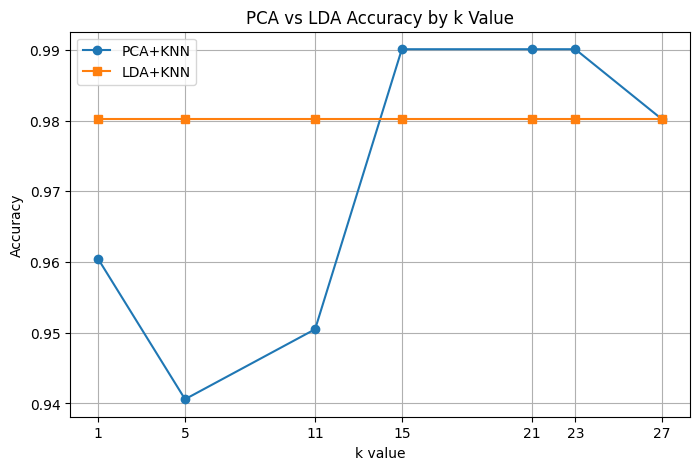

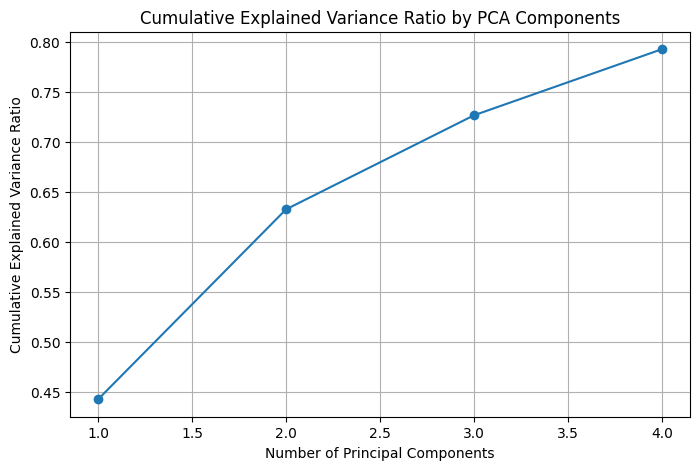

In [17]:
# ============================================================
# 17. k 값별 정확도 시각화
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(resultsdf["k"], resultsdf["PCA_accuracy"], marker="o", label="PCA+KNN")
plt.plot(resultsdf["k"], resultsdf["LDA_accuracy"], marker="s", label="LDA+KNN")
plt.xlabel("k value")
plt.ylabel("Accuracy")
plt.title("PCA vs LDA Accuracy by k Value")
plt.xticks(kvalues)
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# 18. PCA 설명분산비율 시각화
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(evr_zscore) + 1), cev_zscore, marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("Cumulative Explained Variance Ratio by PCA Components")
plt.grid(True)
plt.show()

In [18]:
# ============================================================
# 19. 결과 요약
# ============================================================

summarydf = pd.DataFrame([
    {
        "model": "Min-Max + PCA",
        "accuracy": acc_minmax_pca,
        "malevolent_recall": rep_minmax_pca["Malevolent"]["recall"],
        "macro_f1": rep_minmax_pca["macro avg"]["f1-score"],
        "reduced_dim": Xtrainminmaxpca.shape[1],
    },
    {
        "model": "Min-Max + LDA",
        "accuracy": acc_minmax_lda,
        "malevolent_recall": rep_minmax_lda["Malevolent"]["recall"],
        "macro_f1": rep_minmax_lda["macro avg"]["f1-score"],
        "reduced_dim": Xtrainminmaxlda.shape[1],
    },
    {
        "model": "Z-score + PCA",
        "accuracy": acc_zscore_pca,
        "malevolent_recall": rep_zscore_pca["Malevolent"]["recall"],
        "macro_f1": rep_zscore_pca["macro avg"]["f1-score"],
        "reduced_dim": Xtrainzscorepca.shape[1],
    },
    {
        "model": "Z-score + LDA",
        "accuracy": acc_zscore_lda,
        "malevolent_recall": rep_zscore_lda["Malevolent"]["recall"],
        "macro_f1": rep_zscore_lda["macro avg"]["f1-score"],
        "reduced_dim": Xtrainzscorelda.shape[1],
    },
])

display(summarydf.sort_values("accuracy", ascending=False))

,model,accuracy,malevolent_recall,macro_f1,reduced_dim
2,Z-score + PCA,0.990099,1.000000,0.986528,4
0,Min-Max + PCA,0.980198,0.958333,0.972673,4
1,Min-Max + LDA,0.980198,0.958333,0.972673,1
3,Z-score + LDA,0.980198,0.958333,0.972673,1


# PCA·LDA 기반 KNN 유방암 분류 성능 분석 종합

본 문서는 위의 실험 결과를 바탕으로, PCA와 LDA를 적용한 KNN 분류기의 성능을 종합적으로 비교·분석한 내용이다. 데이터는 Wisconsin Breast Cancer 데이터셋 569개 샘플과 30개 수치형 특성으로 구성되며, 노트북에서는 PyTorch 기반 KNN을 구현하고 차원 축소 전처리로 PCA와 LDA를 적용했다.

## 실험 구성

노트북에서는 Min-Max 정규화와 Z-score 표준화를 각각 적용한 뒤, PCA 또는 LDA로 차원을 축소하고 KNN 분류를 수행했다. PCA는 Z-score 기준으로 4차원까지 축소되었고, LDA는 이진 분류이므로 1차원 `LD1`으로 축소되었다.

훈련/테스트 분할은 앞 468개 샘플을 train, 뒤 101개 샘플을 test로 사용하는 고정 분할 방식으로 수행되었다. 평가는 정확도, 악성 클래스 재현율(`malevolent_recall`), macro F1, 혼동행렬, 그리고 여러 `k` 값에 대한 정확도 비교로 이루어졌다.

## 핵심 결과

단일 설정 비교에서 가장 좋은 성능은 **Z-score + PCA** 조합이 기록했으며, 정확도 0.990099, 악성 재현율 1.000000, macro F1 0.986528을 달성했다. 반면 Min-Max + PCA, Min-Max + LDA, Z-score + LDA는 모두 정확도 0.980198, 악성 재현율 0.958333, macro F1 0.972673으로 동일한 성능을 보였다.

| 모델 | 정확도 | 악성 재현율 | Macro F1 | 축소 차원 |
|---|---:|---:|---:|---:|
| Z-score + PCA | 0.990099 | 1.000000 | 0.986528 | 4 |
| Min-Max + PCA | 0.980198 | 0.958333 | 0.972673 | 4 |
| Min-Max + LDA | 0.980198 | 0.958333 | 0.972673 | 1 |
| Z-score + LDA | 0.980198 | 0.958333 | 0.972673 | 1 |

이 결과는 현재 데이터와 분할 방식에서는 PCA가 반드시 LDA보다 항상 우수하다고 말하기보다, **Z-score 표준화와 결합된 PCA가 가장 안정적으로 작동했다**고 해석하는 것이 적절하다. 특히 악성 샘플 재현율이 1.0이라는 점은, 테스트셋의 악성 샘플을 하나도 놓치지 않았다는 의미이므로 의료 진단 보조 문제에서 매우 중요한 결과다.

## 혼동행렬 해석

Z-score + PCA의 혼동행렬은 실제 양성 77개 중 76개를 정확히 예측하고 1개를 악성으로 분류했으며, 실제 악성 24개는 전부 악성으로 분류했다. 즉, 오분류는 총 1건이며 그마저도 양성을 악성으로 판단한 경우이므로, 악성 누락(false negative)이 없었다는 점이 강점이다.

반면 Z-score + LDA는 실제 양성 77개 중 76개를 맞추고 1개를 악성으로 오분류했으며, 실제 악성 24개 중 23개를 맞추고 1개를 양성으로 잘못 분류했다. Min-Max + PCA와 Min-Max + LDA도 동일한 형태의 혼동행렬을 보여, 전체적으로 2건의 오분류와 1건의 악성 누락이 발생했다.

## k 값 변화에 따른 비교

`k` 값을 1, 5, 11, 15, 21, 23, 27로 바꾸어 비교한 결과, LDA는 모든 `k` 값에서 정확도 0.980198로 일정한 성능을 유지했다. 반면 PCA는 `k=1`에서 0.960396, `k=5`에서 0.940594, `k=11`에서 0.950495로 상대적으로 낮았지만, `k=15`, `21`, `23`에서는 0.990099까지 상승했고 `k=27`에서는 0.980198로 다시 내려갔다.

| k | PCA 정확도 | LDA 정확도 |
|---|---:|---:|
| 1 | 0.960396 | 0.980198 |
| 5 | 0.940594 | 0.980198 |
| 11 | 0.950495 | 0.980198 |
| 15 | 0.990099 | 0.980198 |
| 21 | 0.990099 | 0.980198 |
| 23 | 0.990099 | 0.980198 |
| 27 | 0.980198 | 0.980198 |

이 패턴은 LDA가 저차원 1축으로 데이터를 압축하면서 비교적 **일관된 결정 경계**를 만들었음을 시사한다. 반대로 PCA는 더 높은 차원 정보를 유지하는 대신 `k` 값에 더 민감하게 반응했지만, 적절한 `k`를 선택했을 때는 LDA보다 더 높은 성능을 낼 수 있었다.

## 해석과 시사점

이번 실험의 가장 중요한 포인트는 **차원 축소 알고리즘보다 스케일링 방식과 KNN의 하이퍼파라미터 선택이 함께 성능을 좌우했다**는 점이다. 같은 PCA라도 Min-Max에서는 0.980198에 머물렀지만 Z-score에서는 0.990099까지 올라갔으므로, 거리 기반 분류기에서 표준화 방식의 영향이 크다는 사실을 확인할 수 있다.

또한 LDA는 1차원으로 줄였음에도 모든 설정에서 0.980198의 안정적인 성능을 보였기 때문에, 차원 수를 크게 줄이면서도 해석 가능성과 계산 효율을 확보하려는 목적에는 유리하다. 반면 최고 성능 자체를 목표로 한다면 이번 결과에서는 Z-score + PCA + 중간 이상 `k` 값 조합이 더 적합하다.

## 최종 결론

종합하면, 이번 노트북 실험에서 **최고 성능 모델은 Z-score + PCA + KNN**이며 정확도 0.990099와 악성 재현율 1.000000을 기록했다. **가장 안정적인 모델은 LDA + KNN**으로 볼 수 있으며, `k` 값 변화에 거의 영향을 받지 않고 일정한 0.980198 정확도를 유지했다.

실무적으로는 다음과 같이 해석할 수 있다.

- 최고 정확도와 악성 탐지율이 중요하면 Z-score + PCA를 우선 검토한다.
- 모델 단순화와 안정적 동작이 중요하면 LDA를 고려한다.
- KNN에서는 차원 축소 자체보다도 스케일링 방식과 `k` 탐색이 동등하게 중요하므로, PCA/LDA 비교와 함께 반드시 하이퍼파라미터 탐색을 병행해야 한다.